In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

In [2]:
# Loading Dati (NON SAPPIAMO COSA SIA QUELL'ENCODING)
customers = pd.read_csv('Online_Retail.csv', encoding='iso-8859-1', sep=',', parse_dates=['InvoiceDate'], low_memory=False)

C:\Users\WE572VG\AppData\Local\Temp\ipykernel_27136\2902546260.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customers = pd.read_csv('Online_Retail.csv', encoding='iso-8859-1', sep=',', parse_dates=['InvoiceDate'], low_memory=False)


In [3]:
# Stampo
customers

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [4]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
customers.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


#### c'è un problema con Quantity e UnitPrice in quanto valore masssimo e minimo sono enormi e il minimo è negativo

In [6]:
# elimino tutte le righe in cui 'Quantity' oppure 'UnitPrice' sono negativi
customers = customers[(customers['Quantity'] >= 0) & (customers['UnitPrice'] >= 0)]

In [7]:
# Descrizione non ci importa, ma togliamo righe con CustomerID NaN
customers = customers.dropna(subset=['CustomerID'])

In [8]:
# Preprocessing, creiamo la variabile 'Customer Lifetime Value' per esprimere il totale speso da ciascun cliente
customers['Customer Lifetime Value'] = customers.groupby('CustomerID')['UnitPrice'].transform('sum')

In [9]:
# Total Price
customers['Total Price'] = customers['Quantity'] * customers['UnitPrice']

In [10]:
# Feature Engineering
# Per ogni CustomerID, creiamo delle features aggiuntive

# numero totale di acquisti, spesa media, frequenza di acquisto e paese d'appartenenza (già è Country presente)
customer_features = customers.groupby('CustomerID').agg({
    'Quantity': 'sum',  # Numero di acquisti
    'Total Price': 'mean', # spesa media
    'InvoiceNo': 'nunique',  # frequenza acquisto (numero di transazioni)
}).rename(columns={
    'Quantity': 'Total Purchases',
    'Total Price': 'Average Spend',
    'InvoiceNo': 'Total Transactions'
}).reset_index()

In [11]:
customer_features.describe()

,CustomerID,Total Purchases,Average Spend,Total Transactions
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,1194.214335,68.303655,4.271952
std,1721.889758,5055.603049,1467.745469,7.705493
min,12346.000000,1.000000,0.000000,1.000000
25%,13812.500000,160.000000,12.353054,1.000000
50%,15299.000000,379.000000,17.716923,2.000000
75%,16778.500000,993.000000,24.848410,5.000000
max,18287.000000,197491.000000,77183.600000,210.000000


In [12]:
# Normalizzazione dei dati per renderli equiparabili
X = customer_features[['Total Purchases', 'Average Spend', 'Total Transactions']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

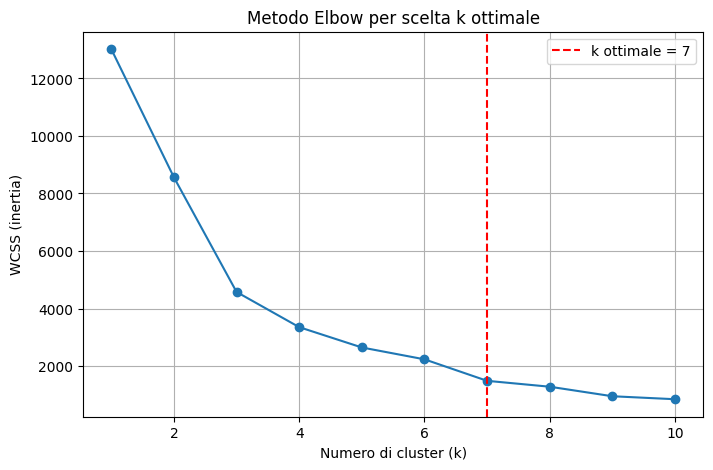

Optimal k (Elbow): 7


In [13]:
# Primo Algoritmo di Clustering KMeans
# Facciamo Elbow method per capire quanti clusters utilizzare
wcss = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)  # inertia = Within-Cluster Sum of Squares

plt.figure(figsize=(8, 5))
plt.plot(K, wcss, marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("WCSS (inertia)")
plt.title("Metodo Elbow per scelta k ottimale")
plt.grid(True)
optimal_k = 7
plt.axvline(optimal_k, color='red', linestyle='--', label=f'k ottimale = {optimal_k}')
plt.legend()
plt.show()
print(f"Optimal k (Elbow): {optimal_k}")

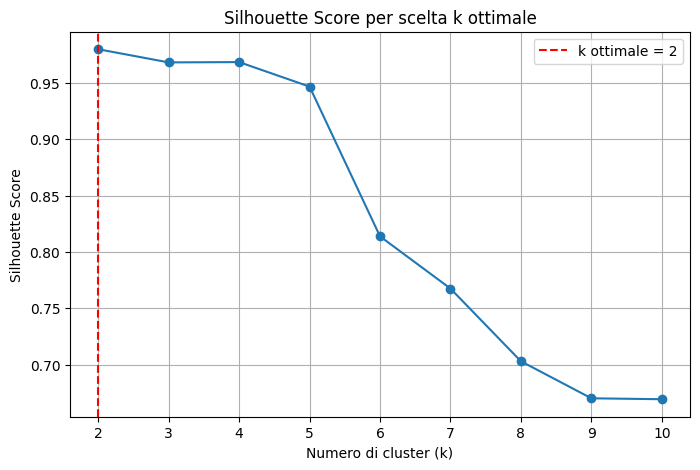

Numero ottimale di cluster secondo Silhouette: 2


In [15]:
silhouette_scores = []
K = range(2, 11)  # Silhouette non è definito per k=1

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(K), silhouette_scores, marker='o')
plt.xlabel("Numero di cluster (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score per scelta k ottimale")
plt.grid(True)

# Il valore di k con il silhouette score più alto è il migliore
optimal_k = K[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(optimal_k, color='red', linestyle='--', label=f'k ottimale = {optimal_k}')
plt.legend()
plt.show()
print(f"Numero ottimale di cluster secondo Silhouette: {optimal_k}")

C:\Users\WE572VG\AppData\Local\Temp\ipykernel_27136\3912787845.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  dbscan3d = ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=colors_dbscan, cmap='Set1', s=50, edgecolor='k')


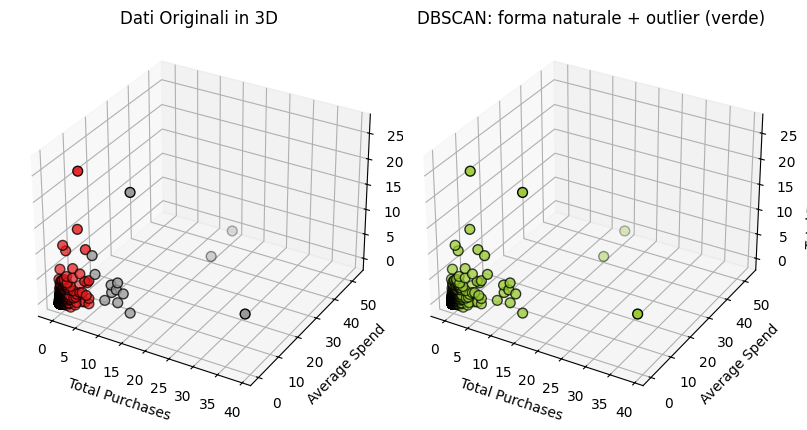

In [25]:
# KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)
customer_features["Clusters"] = labels

# DBSCAN clustering (basato sulla densità, senza specificare k)
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Assegna colori ai cluster DBSCAN (grigio per outlier, colori per cluster)
unique_labels = set(dbscan_labels)
palette = sns.color_palette("Set2", len(unique_labels))
color_map = {
    label: palette[i] if label != -1 else (0.6, 0.8, 0.2)  # grigio per outlier
    for i, label in enumerate(sorted(unique_labels))
}
colors_dbscan = [color_map[label] for label in dbscan_labels]

# Visualizzazione: k-Means vs DBSCAN IN 3D con Axes3D
# Creazione visualizzazione 3D dei clusters derivanti avendo tre features per ogni CustomerID
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 20))

# Plot originale in 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# KMeans
kmeans3d = ax1.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=customer_features["Clusters"], cmap='Set1', s=50, edgecolor='k')
ax1.set_title("Dati Originali in 3D")
ax1.set_xlabel("Total Purchases")
ax1.set_ylabel("Average Spend")
ax1.set_zlabel("Total Transactions")
ax1.grid(True)

# DBSCAN
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
dbscan3d = ax2.scatter(X_scaled[:, 0], X_scaled[:, 1], X_scaled[:, 2], c=colors_dbscan, cmap='Set1', s=50, edgecolor='k')
ax2.set_title("DBSCAN: forma naturale + outlier (verde)")
ax2.set_xlabel("Total Purchases")
ax2.set_ylabel("Average Spend")
ax2.set_zlabel("Total Transactions")
ax2.grid(True)

plt.tight_layout()
plt.show()
